In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import *
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import *
from Triangle_GB.TDIFly import *

import bilby
import multiprocessing
if __name__ == "__main__":
    multiprocessing.set_start_method("fork")

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


No pyseobnr.
no cupy 
no cupy 


##  Orbit settings
Default LISA-Taiji-TianQin orbit configuration with random initial phases 

In [2]:
random_initial_orbit_phases = {"Taiji": 6.10414095, "LISA": 0.12801155, "TianQin": 1.22975531}

orbit_configs = {
    "Taiji":  {"L": 3e9, "kap": 0., "lam": random_initial_orbit_phases["Taiji"],
               "dt": DAY, "Tobs": 5.*YEAR, "sacc": 3e-15, "soms": 8e-12,
               "conf_scale": (2.5e9 / 3e9) ** 2},
    "LISA":   {"L": 2.5e9, "kap": -np.deg2rad(40.), "lam": random_initial_orbit_phases["LISA"],
               "dt": DAY, "Tobs": 5.*YEAR, "sacc": 3e-15, "soms": 15e-12,
               "conf_scale": 1.0},
    "TianQin":{"L": np.sqrt(3.)*1e8, "kappa0": random_initial_orbit_phases["TianQin"],
               "kappae": -np.deg2rad(20.), "dt": 6000., "Tobs": 5.*YEAR,
               "sacc": 1e-15, "soms": 1e-12,
               "conf_scale": (np.sqrt(3.) * 1e8 / 2.5e9) ** 2},
}

mission_list = ["TianQin", "Taiji", "LISA"]

orbits = []
for mission in mission_list:
    cfg = orbit_configs[mission]
    if mission in ["Taiji", "LISA"]:
        orbit = HeliocentricEqualArmAnalyticOrbit(
            L=cfg["L"], kap=cfg["kap"], lam=cfg["lam"],
            dt=cfg["dt"], Tobs=cfg["Tobs"], pn_order=0)
    else:
        orbit = GeocentricEqualArmAnalyticOrbit(
            L=cfg["L"], kappa0=cfg["kappa0"], kappa_earth=cfg["kappae"],
            dt=cfg["dt"], Tobs=cfg["Tobs"], pn_order=0)
    orbits.append(orbit)

print(f"Orbits created for: {mission_list}")

Orbits created for: ['TianQin', 'Taiji', 'LISA']


## Analytic noise model

This is an instrumental-noise-only example.

In [3]:
# ============================================================
# Analytic noise model (function-wrapped)
#
#   * Instrumental noise: A/E channel PSD from TDIPSDs, exactly as
#     in network_PE.ipynb  ->  TDIPSDs(...).PSD_A2(f)
#   * Galactic-binary confusion foreground: currently DISABLED
#     (galactic_confusion_psd / galactic_confusion_csd return all
#     zeros).  The analytic Robson-Cornish-Liu (2019) fit is kept in
#     the docstring and can be re-enabled inside the function.
#   * PSD / CSD / covariance construction follows network_PE.ipynb:
#
#         C(f) = S(f) / (4 Delta_f),        Delta_f = 1 / Tobs
#
#     where S(f) is the full (2N x 2N) spectral matrix in the channel
#     ordering  [det0_A, det0_E, det1_A, det1_E, ...].  The noise model
#     is selected automatically from the optional arguments:
#
#         conf_psd_dict is None                     -> instrumental only
#                                                      (diagonal S)
#         conf_psd_dict given, conf_csd_dict is None -> instrumental +
#                                                      confusion auto-PSD
#                                                      (block-diagonal S)
#         both given                                -> full network S
#                                                      (incl. cross-detector
#                                                      CSD blocks)
#
#     The covariance used in the likelihood is built by
#     ``build_network_covariance`` / ``build_network_inv_covariance``.
#     The noise *realisation* is drawn by ``generate_network_noise``,
#     which for the present (instrumental-noise-only) configuration
#     generates each channel directly from its PSD -- see its docstring
#     for the validity condition.
#
#   * GB signals are narrowband: all PSDs/CSDs are evaluated on the
#     narrow frequency band around f0 when constructing the likelihood
#     / data, and the frequency resolution is set by 1/Tobs of the grid.
# ============================================================


def galactic_confusion_psd(freqs, L=2.5e9, conf_scale=None):
    """Confusion-foreground PSD placeholder: currently returns all zeros
    (confusion noise disabled).

    The analytic Robson-Cornish-Liu (2019) fit

        S_conf(f) = (1/2) * A * f^(-7/3) * exp[-(f/f1)^alpha]
                    * (1 + tanh((fknee - f)/f2)) * conf_scale

    can be re-enabled by returning that expression instead of zeros.
    The signature is kept so downstream code (``build_conf_psd_dict``,
    ``build_network_covariance``) works unchanged.

    Parameters
    ----------
    freqs : (Nf,) array
        Frequency grid [Hz].
    L : float
        Detector arm length [m] (unused while disabled).
    conf_scale : float, optional
        Overall amplitude scale (unused while disabled).

    Returns
    -------
    S_conf : (Nf,) array
        One-sided confusion PSD [1/Hz] (all zeros).
    """
    f = np.atleast_1d(np.asarray(freqs, dtype=float))
    return np.zeros_like(f)


def galactic_confusion_csd(freqs, L1=2.5e9, L2=2.5e9, conf_scale=None):
    """Cross-detector confusion CSD placeholder: currently returns all
    zeros (confusion cross-spectra disabled / neglected).

    When enabled, this should return the (complex, Hermitian) overlap
    reduced cross-spectral density S_csd^{d1 d2}(f) between two
    detectors in the same A/E channel pair.  The signature is kept so
    ``build_conf_csd_dict`` and ``build_network_covariance`` work
    unchanged.

    Parameters
    ----------
    freqs : (Nf,) array
        Frequency grid [Hz].
    L1, L2 : float
        Arm lengths of the two detectors [m] (unused while disabled).
    conf_scale : float, optional
        Overall amplitude scale (unused while disabled).

    Returns
    -------
    S_csd : (Nf,) complex array
        Cross-spectral density (all zeros).
    """
    f = np.atleast_1d(np.asarray(freqs, dtype=float))
    return np.zeros_like(f, dtype=complex)


def build_inst_psd_dict(freqs, mission_list, orbit_configs):
    """Instrumental A/E PSD for each detector (same PSD for A and E,
    as in network_PE.ipynb).  Returns {det: (2, Nf) array}."""
    inst_psd = {}
    for det in mission_list:
        cfg = orbit_configs[det]
        psd_func = TDIPSDs(sacc=cfg["sacc"], sro=cfg["soms"], L=cfg["L"])
        # Evaluate on a DC-free grid to avoid 1/f singularities,
        # then patch the DC bin afterwards.
        f_eval = np.asarray(freqs, dtype=float)
        if f_eval[0] == 0.:
            f_eval = f_eval.copy()
            f_eval[0] = f_eval[1]
        npsd = psd_func.PSD_A2(f_eval)
        npsd = np.nan_to_num(npsd, nan=0.)      # same as network_PE.ipynb
        if freqs[0] == 0.:
            npsd[0] = npsd[1]                   # avoid the DC singularity
        eps0 = 1e-50
        npsd[npsd < eps0] = eps0
        inst_psd[det] = np.array([npsd, npsd])  # (2, Nf)  [A, E]
    return inst_psd


def build_conf_psd_dict(freqs, mission_list, orbit_configs):
    """Confusion auto-PSD for each detector's A/E channels (currently all
    zeros, since the confusion foreground is disabled).  Returns
    {det: (2, Nf) array}."""
    conf_psd = {}
    for det in mission_list:
        cfg = orbit_configs[det]
        S = galactic_confusion_psd(
            freqs, L=cfg["L"], conf_scale=cfg.get("conf_scale", None))
        conf_psd[det] = np.array([S, S])  # (2, Nf)  [A, E]
    return conf_psd


def build_conf_csd_dict(freqs, mission_list, orbit_configs):
    """Cross-detector confusion CSD blocks (currently all zeros, since the
    confusion cross-spectra are disabled).

    Returns a nested dict following the layout of network_PE.ipynb::

        conf_csd["det1_det2"]["ch1_ch2"] = (Nf,) complex array

    for every upper-triangle detector pair and ch1, ch2 in {A, E}.
    Pass ``None`` to ``build_network_covariance`` instead to omit the
    cross-detector blocks altogether (the zero arrays give the same
    covariance).
    """
    conf_csd = {}
    for i, det1 in enumerate(mission_list):
        for j, det2 in enumerate(mission_list):
            if i >= j:
                continue
            cfg1, cfg2 = orbit_configs[det1], orbit_configs[det2]
            S_csd = galactic_confusion_csd(
                freqs, L1=cfg1["L"], L2=cfg2["L"],
                conf_scale=cfg1.get("conf_scale", None))
            conf_csd[f"{det1}_{det2}"] = {
                f"{c1}_{c2}": S_csd
                for c1 in ("A", "E") for c2 in ("A", "E")}
    return conf_csd


def build_network_spectral_matrix(
        inst_psd_dict, conf_psd_dict=None, conf_csd_dict=None,
        det_order=None):
    """Assemble the full (Nf, 2N, 2N) spectral matrix S(f).

    Frequency-first convention, channel ordering
    [det0_A, det0_E, det1_A, det1_E, ...] -- identical to
    network_PE.ipynb.

    Returns
    -------
    S_all : (Nf, 2N, 2N) complex array
    det_list : list of str
        Ordered detector names.
    """
    det_list = det_order or sorted(inst_psd_dict.keys())
    N = len(det_list)
    n_f = inst_psd_dict[det_list[0]].shape[1]

    use_conf_psd = conf_psd_dict is not None
    use_conf_csd = conf_csd_dict is not None

    S_all = np.zeros((n_f, 2 * N, 2 * N), dtype=complex)
    for k in range(n_f):
        S = np.zeros((2 * N, 2 * N), dtype=complex)

        # --- diagonal 2x2 blocks: instrumental (+ confusion auto-PSD) ---
        for i, d in enumerate(det_list):
            row = 2 * i
            if use_conf_psd:
                S[row, row] = (conf_psd_dict[d][0][k]
                               + inst_psd_dict[d][0][k])
                S[row + 1, row + 1] = (conf_psd_dict[d][1][k]
                                       + inst_psd_dict[d][1][k])
            else:
                S[row, row] = inst_psd_dict[d][0][k]
                S[row + 1, row + 1] = inst_psd_dict[d][1][k]

        # --- off-diagonal 2x2 blocks: cross-detector CSDs ---
        if use_conf_csd:
            for i, d1 in enumerate(det_list):
                for j, d2 in enumerate(det_list):
                    if i >= j:
                        continue
                    pair = f"{d1}_{d2}"
                    if pair not in conf_csd_dict:
                        continue
                    row, col = 2 * i, 2 * j
                    for ci, c1 in enumerate(["A", "E"]):
                        for cj, c2 in enumerate(["A", "E"]):
                            val = conf_csd_dict[pair][f"{c1}_{c2}"][k]
                            S[row + ci, col + cj] = val
                            S[col + cj, row + ci] = np.conj(val)

        S_all[k, :, :] = S

    return S_all, det_list


def build_network_covariance(
        inst_psd_dict, conf_psd_dict=None, conf_csd_dict=None,
        delta_f=1., det_order=None):
    """Covariance matrix C(f) = S(f) / (4 Delta_f) at all frequencies.

    Returns
    -------
    cov : (Nf, 2N, 2N) complex array
    det_list : list of str
        Ordered detector names.
    """
    S_all, det_list = build_network_spectral_matrix(
        inst_psd_dict, conf_psd_dict, conf_csd_dict, det_order)
    return S_all / (4. * delta_f), det_list


def build_network_inv_covariance(
        inst_psd_dict, conf_psd_dict=None, conf_csd_dict=None,
        delta_f=1., det_order=None):
    """Build the inverse network covariance matrix at all frequencies.

    The covariance at each frequency is

        C(f) = S(f) / (4 Delta_f)

    where S(f) is the full (2N x 2N) PSD/CSD matrix.

    The noise model is determined automatically from the optional arguments:

        - ``conf_psd_dict`` is None: instrumental noise only (diagonal)
        - ``conf_psd_dict`` is not None, ``conf_csd_dict`` is None:
          instrumental + confusion auto-PSD (block-diagonal)
        - both are not None: full network covariance (instrumental +
          confusion auto-PSD + cross-detector CSD blocks)

    Parameters
    ----------
    inst_psd_dict : dict  {det_name: (2, Nf) array}
        Instrumental noise PSD for A and E channels of each detector.
    conf_psd_dict : dict  {det_name: (2, Nf) array}, optional
        Smoothed confusion auto-PSD for A and E channels of each detector.
    conf_csd_dict : dict of dict, optional
        Nested dict: conf_csd["det1_det2"]["ch1_ch2"] = (Nf,) complex array.
        Only upper-triangle pairs are needed.
    delta_f : float
        Frequency bin width Delta f [Hz].  (Equivalently 1/Tobs.)
    det_order : list of str, optional
        Explicit detector ordering.  Default: sorted keys of inst_psd_dict.

    Returns
    -------
    cov_inv : (Nf, 2N, 2N) complex array
        C^{-1}(f) at each frequency (frequency-first, matching
        HMLikelihood's convention).
    det_list : list of str
        Ordered detector names.
    """
    cov, det_list = build_network_covariance(
        inst_psd_dict, conf_psd_dict, conf_csd_dict, delta_f, det_order)
    return np.linalg.inv(cov), det_list


def generate_network_noise(inst_psd_dict, delta_f=1., det_order=None,
                           seed=None):
    """Draw one noise realisation from the *instrumental-noise-only* model.

    Each TDI channel is generated independently from its own one-sided
    PSD:

        n(f_k) = sigma_k * (z_r + i z_i),
        sigma_k = sqrt(S_k / (4 Delta_f)),      z_r, z_i ~ N(0, 1),

    so that E[|n|^2] = 2 sigma_k^2 = S_k / (2 Delta_f), i.e. the discrete
    equivalent of the one-sided PSD S_k.  This is exactly the recipe used
    in network_PE.ipynb (there written inline as
    ``sigma = sqrt(S / (4 * df)); n = sigma * (randn + 1j * randn)``).

    !! VALIDITY -- INSTRUMENTAL NOISE ONLY !!

    Generating each channel independently is correct only when the noise
    spectral matrix S is *diagonal*, i.e. when the noise consists of
    uncorrelated instrumental contributions (no confusion foreground and
    no cross-detector correlations).  That is the configuration used in
    this notebook (``conf_psd_dict`` / ``conf_csd_dict`` are all zeros on
    the likelihood side as well), so the realisation and the covariance
    are matched by construction.

    If the confusion foreground is ever switched on (auto-PSDs and/or
    cross-detector CSD blocks), this function must NOT be used as is: the
    data would then be missing the very correlations present in the
    covariance, and the residuals would not follow C.  In that case draw
    from the full covariance instead, e.g.

        cov, _ = build_network_covariance(inst_psd_dict, conf_psd_dict,
                                          conf_csd_dict, delta_f, det_order)
        L = np.linalg.cholesky(cov)          # (Nf, 2N, 2N)
        z = randn(Nf, 2N) + 1j * randn(Nf, 2N)
        noise = np.einsum("kij,kj->ki", L, z).T          # (2N, Nf)

    Parameters
    ----------
    inst_psd_dict : dict  {det_name: (2, Nf) array}
        Instrumental noise PSD for the A and E channels of each detector.
    delta_f : float
        Frequency bin width Delta f [Hz] (= 1/Tobs).
    det_order : list of str, optional
        Explicit detector ordering.  Default: sorted keys of inst_psd_dict.
    seed : int, optional
        Seed for the noise realisation.

    Returns
    -------
    noise : (2N, Nf) complex array
        Ordered as [det0_A, det0_E, det1_A, det1_E, ...].
    """
    rng = np.random.default_rng(seed)
    det_list = det_order or sorted(inst_psd_dict.keys())

    parts = []
    for det in det_list:
        # (2, Nf): independent A and E channels, each with its own PSD
        sigma = np.sqrt(np.asarray(inst_psd_dict[det]) / (4. * delta_f))
        parts.append(sigma * (rng.standard_normal(sigma.shape)
                              + 1j * rng.standard_normal(sigma.shape)))

    return np.concatenate(parts, axis=0)         # (2N, Nf)

In [4]:
# ============================================================
# Data grid (common to all detectors)
#
#   GB signals are narrowband, so the analysis is restricted to a
#   small band around f0 and the noise PSDs are evaluated directly
#   on that band where they are needed (see the covariance cell
#   below).  The full grid defined here is the time / frequency grid
#   the network TDI generator works on, together with its frequency
#   resolution df = 1 / Tobs.
# ============================================================
Tobs_gb = 4. * YEAR
dt_gb = 10.
Tobs_gb = int(Tobs_gb / dt_gb) * dt_gb
data_time = np.arange(int(Tobs_gb / dt_gb)) * dt_gb
freq_data = np.fft.rfftfreq(n=int(Tobs_gb / dt_gb), d=dt_gb)
delta_f_gb = 1. / Tobs_gb

print(f"GB Tobs = {Tobs_gb / YEAR:.1f} yr,  dt = {dt_gb} s,  "
      f"N_time = {len(data_time)},  Nf = {len(freq_data)},  "
      f"df = {delta_f_gb:.2e} Hz")

GB Tobs = 4.0 yr,  dt = 10.0 s,  N_time = 12623259,  Nf = 6311630,  df = 7.92e-09 Hz


## Network waveform generation

In [5]:
# ============================================================
# TDIFlyGBNetwork:  network version of TDIFlyGB
#
#   The class lives in this repository's own package
#   (Triangle_GB/TDIFly.py) and is imported here:
#     * Orbit-dependent quantities (arm vectors, delays, positions on
#       the sparse time grid) are precomputed ONCE per detector at
#       construction.
#     * Source-dependent quantities (wave vector, phase evolution,
#       carrier frequency, inclination factors) are computed ONCE per
#       call and shared by all detectors -> no duplicated computation
#       between detectors.
#     * The per-detector sparse TDI response is still computed per
#       detector (different orbits), then converted to A/E and filled
#       onto the common frequency band.
# ============================================================

from Triangle_GB.TDIFly import TDIFlyGBNetwork

X2_strings = TDIFly.X2_strings
Y2_strings = TDIStringManipulation.TDIStringCyc(X2_strings)
Z2_strings = TDIStringManipulation.TDIStringCyc(Y2_strings)

# ---- instantiate ONE network generator handling all detectors ----
gen_network = TDIFlyGBNetwork(
    orbits=orbits,
    Pstring_list=[X2_strings, Y2_strings, Z2_strings],
    tcb_times=data_time.copy(),
    Nsparse=1024,
    use_gpu=False,
)
print(f"TDIFlyGBNetwork created: {gen_network.Ndet} detectors, "
      f"full_freq grid matches freq_data: "
      f"{np.allclose(np.asarray(gen_network.full_freq), freq_data)}")

TDIFlyGBNetwork created: 3 detectors, full_freq grid matches freq_data: True


## Injected GB source parameters

In [6]:
# ============================================================
# Injected GB source parameters (fixed seed -> reproducible).
#
#   INSTRUMENTAL-NOISE-ONLY reference case: the confusion
#   foreground is switched off in the noise model (see the
#   noise-model cell above), so f0 is placed in the band where the
#   instrumental noise dominates for every mission (>= ~4 mHz for
#   LISA and Taiji, and over the whole band for TianQin).  The
#   network SNR and the Fisher errors obtained below must NOT be
#   read as foreground-limited sensitivities.
# ============================================================
rng = np.random.default_rng(114514)

f0_gb = 3.0e-3                     # [Hz]
true_gb_parameters = {
    "A":           1.0e-22,        # amplitude (TDIFlyGB: A = h0/2, one-sided)
    "f0":          f0_gb,
    "fdot0":       2.0e-17,        # [Hz/s], weak chirp (Mc ~ 0.2 Msun)
    "inclination": rng.uniform(0., PI),
    "longitude":   rng.uniform(0., TWOPI),
    "latitude":    np.arcsin(rng.uniform(-1., 1.)),
    "phase0":      rng.uniform(0., TWOPI),
    "psi":         rng.uniform(0., PI),
}
print(f"f0 = {true_gb_parameters['f0']:.6e} Hz,  "
      f"A  = {true_gb_parameters['A']:.3e}")

f0 = 3.000000e-03 Hz,  A  = 1.000e-22


##  Generate the GB signal on a shared narrow band

Shared band: 3202 bins, [2.9873e-03, 3.0127e-03] Hz
Joint GB signal: (6, 3202)


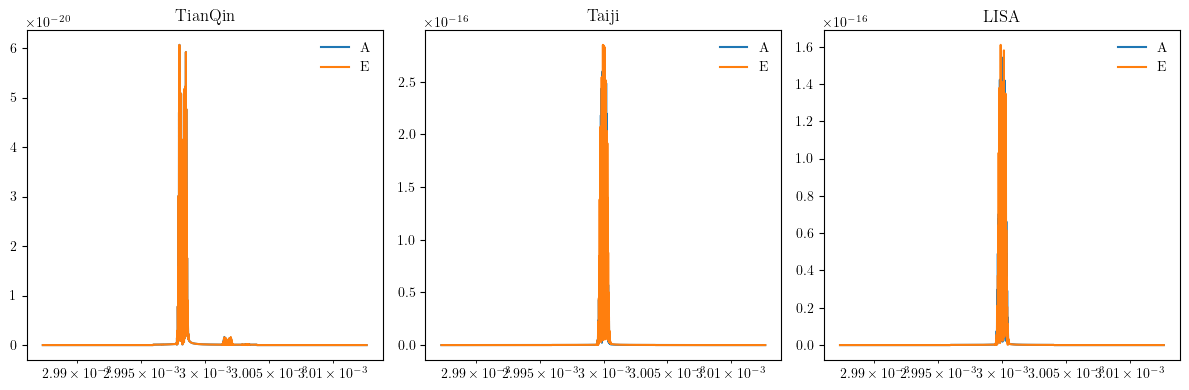

In [7]:
# ============================================================
# Narrow band around f0 (GB signals are narrowband):
#   the band width covers Doppler modulation + chirp + spectral
#   padding of the carrier-centred heterodyne spectrum.
# ============================================================
f0_gb = true_gb_parameters["f0"]

# TianQin-style generous band width (~0.01 mHz), sufficient for all detectors
band_half = 4. / (3.65 * DAY)
band_idx_shared = np.where(np.abs(freq_data - f0_gb) < band_half)[0]
freq_band_shared = freq_data[band_idx_shared]
print(f"Shared band: {len(freq_band_shared)} bins, "
      f"[{freq_band_shared[0]:.4e}, {freq_band_shared[-1]:.4e}] Hz")

# ---- joint network signal: (2*Ndet, Nf_band) ----
signal_joint = np.squeeze(np.asarray(gen_network.response_on_band(
    parameters=true_gb_parameters,
    StartBound=int(band_idx_shared[0]),
    EndBound=int(band_idx_shared[-1]),
)), axis=1)
print(f"Joint GB signal: {signal_joint.shape}")

# ---- quick plot ----
plt.figure(figsize=(12, 4))
for i_det, det in enumerate(mission_list):
    plt.subplot(131 + i_det)
    plt.semilogx(freq_band_shared, np.abs(signal_joint[i_det * 2]), label="A")
    plt.semilogx(freq_band_shared, np.abs(signal_joint[i_det * 2 + 1]), label="E")
    plt.title(det)
    plt.legend(loc="upper right", frameon=False)
plt.tight_layout()

## Build noisy data 

In [8]:
# ============================================================
# GB-band PSDs and network covariance
#   Same construction as network_PE.ipynb:
#       C(f) = S(f) / (4*df),   df = 1/Tobs
#   with S the full (2N x 2N) PSD/CSD matrix in the channel ordering
#       [TianQin_A, TianQin_E, Taiji_A, Taiji_E, LISA_A, LISA_E]
#   Only the GB narrow band around f0 is used (narrowband signals),
#   so the PSDs are evaluated directly on that band.
#
#   INSTRUMENTAL-NOISE-ONLY model: the confusion auto-PSDs and the
#   cross-detector CSD blocks are all zero, so S reduces to the
#   diagonal instrumental spectral matrix (S_A = S_E = PSD_A2 per
#   detector, i.e. C_inst of the paper under the equal-arm and
#   equal-noise assumptions).  Passing the (zero) CSD dict or None
#   is therefore equivalent.
# ============================================================
inst_psd_band = build_inst_psd_dict(freq_band_shared, mission_list,
                                    orbit_configs)
conf_psd_band = build_conf_psd_dict(freq_band_shared, mission_list,
                                    orbit_configs)
conf_csd_band = build_conf_csd_dict(freq_band_shared, mission_list,
                                    orbit_configs)
cov_inv, det_list = build_network_inv_covariance(
    inst_psd_band, conf_psd_dict=conf_psd_band,
    conf_csd_dict=conf_csd_band, delta_f=delta_f_gb,
    det_order=mission_list)

def network_covariance_snr(h, inv_cov):
    """SNR = sqrt(h† C^{-1} h) for joint network data."""
    r = h.T
    rd = np.conjugate(r)[:, np.newaxis, :]
    rv = r[:, :, np.newaxis]
    tmp = np.matmul(rd, inv_cov)
    return float(np.sqrt(np.real(np.sum(np.matmul(tmp, rv)))))


snr_injected = network_covariance_snr(signal_joint, cov_inv)
print(f"Injected GB network SNR: {snr_injected:.1f}")

# ============================================================
# Generate the instrumental noise directly from the analytic PSDs
# (PSD-only / diagonal model: the A and E channels and the three
# detectors are mutually independent) and build the noisy data
# (signal + noise realisation)
# ============================================================
noise_seed = 22222
noise_joint = generate_network_noise(
    inst_psd_band, delta_f=delta_f_gb,
    det_order=mission_list, seed=noise_seed)

data_joint = signal_joint + noise_joint

Injected GB network SNR: 319.8


##  Network likelihood 

In [9]:
class GBNetworkLikelihood(bilby.Likelihood):
    """Full network likelihood for Galactic binaries (analytic noise model).

    Joint data vector at frequency f_k:
        d(f_k) = [det0_A, det0_E, det1_A, det1_E, ...](f_k)
    with the covariance C(f_k) = S(f_k) / (4*df) returned by
    ``build_network_covariance`` / ``build_network_inv_covariance``
    (instrumental PSD + confusion auto-PSD, optionally cross-detector
    CSD blocks).  No heterodyne acceleration is needed: GB signals are
    narrowband and TDIFlyGBNetwork is fast enough.
    """

    def __init__(self, network_generator, data_joint, band_idx, cov_inv,
                 det_names=None):
        super().__init__(parameters={
            'A': None, 'f0': None, 'fdot0': None,
            'inclination': None, 'latitude': None, 'longitude': None,
            'phase0': None, 'psi': None})
        self.generator = network_generator
        self.data_joint = data_joint
        self.band_idx = band_idx
        self.cov_inv = cov_inv
        self.N_det = network_generator.Ndet
        self.det_names = det_names or [f"det{i}" for i in range(self.N_det)]

    def _compute_template(self, parameters):
        """Joint GB template on the shared frequency band: (2*N_det, Nf)."""
        h = self.generator.response_on_band(
            parameters=parameters,
            StartBound=int(self.band_idx[0]),
            EndBound=int(self.band_idx[-1]))
        return np.squeeze(np.asarray(h), axis=1)

    def log_likelihood(self):
        template = self._compute_template(self.parameters)
        residual = self.data_joint - template
        r = residual.T
        rd = np.conjugate(r)[:, np.newaxis, :]
        rv = r[:, :, np.newaxis]
        tmp = np.matmul(rd, self.cov_inv)
        snr2 = np.real(np.sum(np.matmul(tmp, rv)))
        return -0.5 * snr2

    def network_snr(self, parameters):
        template = self._compute_template(parameters)
        r = template.T
        rd = np.conjugate(r)[:, np.newaxis, :]
        rv = r[:, :, np.newaxis]
        tmp = np.matmul(rd, self.cov_inv)
        return float(np.sqrt(np.real(np.sum(np.matmul(tmp, rv)))))


like = GBNetworkLikelihood(
    network_generator=gen_network, data_joint=data_joint,
    band_idx=band_idx_shared, cov_inv=cov_inv, det_names=mission_list)

like.parameters = true_gb_parameters.copy()
print(f"LL at truth: {like.log_likelihood():.2f}")
print(f"SNR from likelihood: {like.network_snr(true_gb_parameters):.1f}")

LL at truth: -19073.45
SNR from likelihood: 319.8


##  Fisher matrix & priors

In [10]:
# ============================================================
# Full Fisher matrix via MultiChannelFisher (Triangle_BBH)
# with the inverse covariance of the instrumental-noise-only
# analytic model built above.
# ============================================================
from Triangle_BBH.Fisher import MultiChannelFisher


def gb_waveform_wrapper(params, freqs):
    """Stacked GB network response: (2*N_det, Nf_band) complex array."""
    h = gen_network.response_on_band(
        parameters=params,
        StartBound=int(band_idx_shared[0]),
        EndBound=int(band_idx_shared[-1]))
    return np.squeeze(np.asarray(h), axis=1)


# Step sizes for all 8 GB parameters (negative -> auto-tune)
analyze_param_step_dict = {
    "A":           -true_gb_parameters["A"] * 1e-4,
    "f0":          -1e-10,
    "fdot0":       -1e-18,
    "inclination": -1e-4,
    "longitude":   -1e-4,
    "latitude":    -1e-4,
    "phase0":      -1e-4,
    "psi":         -1e-4,
}

mcf = MultiChannelFisher(
    waveform_generator=gb_waveform_wrapper,
    param_dict=true_gb_parameters.copy(),
    analyze_param_step_dict=analyze_param_step_dict.copy(),
    frequency=freq_band_shared,
    inverse_covariance=cov_inv,
    verbose=1,
)

print("Auto-tuning step sizes ...")
mcf.auto_test_step(threshold=1e-3)
mcf.calculate_Fisher()
mcf.calculate_errors()

fisher_sigmas = mcf.param_errors.copy()
print("\nFisher 1-sigma errors (instrumental-noise-only model):")
for p, sigma in fisher_sigmas.items():
    print(f"  sigma({p:12s}) = {sigma:.3e}")

# ============================================================
# Priors:
#   A, f0, fdot0 -> 10-sigma Fisher ranges around the truth
#                   (fdot0 is additionally clipped to its physical
#                   range, see below)
#   sky location -> isotropic priors
#   inclination, phase0, psi -> physically motivated priors
# ============================================================
priors = bilby.core.prior.PriorDict()

A_lo = max(true_gb_parameters["A"] - 10. * fisher_sigmas["A"], 1e-26)
A_hi = true_gb_parameters["A"] + 10. * fisher_sigmas["A"]
priors["A"] = bilby.prior.Uniform(A_lo, A_hi, name='A', latex_label=r'$A$')

f0_lo = max(true_gb_parameters["f0"] - 10. * fisher_sigmas["f0"],
            freq_band_shared[1])
f0_hi = min(true_gb_parameters["f0"] + 10. * fisher_sigmas["f0"],
            freq_band_shared[-2])
priors["f0"] = bilby.prior.Uniform(f0_lo, f0_hi, name="f0",
                                   latex_label=r'$f_0$')

priors["latitude"] = bilby.prior.Cosine(-PI / 2., PI / 2., name="latitude",
                                        latex_label=r'$\beta$')
priors["longitude"] = bilby.prior.Uniform(0., TWOPI, name="longitude",
                                          latex_label=r'$\lambda$',
                                          boundary="periodic")

# fdot0: physical inspiral range, clipped to the 10-sigma Fisher
# interval around the injection.
#   * fdot0 > 0 for an inspiralling (chirp-up) binary -- negative
#     values are unphysical and can bias the prior volume;
#   * TDIFlyGB.fdot_upper_bound(f) = 1e-6 * f^(11/3) is the Newtonian
#     quadrupole bound fdot = (96/5) pi^(8/3) (G Mc/c^3)^(5/3) f^(11/3),
#     evaluated at the injected f0 (i.e. Mc ~ 1.4 Msun).
fdot_true = true_gb_parameters["fdot0"]
fdot_lo = max(0., fdot_true - 10. * fisher_sigmas["fdot0"])
fdot_hi = min(TDIFlyGB.fdot_upper_bound(true_gb_parameters["f0"]),
              fdot_true + 10. * fisher_sigmas["fdot0"])
priors["fdot0"] = bilby.prior.Uniform(fdot_lo, fdot_hi, name="fdot0",
                                      latex_label=r'$\dot{f}_0$')

priors["inclination"] = bilby.prior.Sine(0., PI, name="inclination",
                                         latex_label=r'$\iota$')
priors["phase0"] = bilby.prior.Uniform(0., TWOPI, name="phase0",
                                       latex_label=r'$\varphi_0$',
                                       boundary="periodic")
priors["psi"] = bilby.prior.Uniform(0., PI, name="psi",
                                    latex_label=r'$\psi$',
                                    boundary="periodic")
priors

no cupy
No CuPy or GPU PhenomHM module.
has BBHx waveform
8 parameters in total: ['A', 'f0', 'fdot0', 'inclination', 'longitude', 'latitude', 'phase0', 'psi']
8 analyzed parameters: ['A', 'f0', 'fdot0', 'inclination', 'longitude', 'latitude', 'phase0', 'psi']
parameters whose steps should be tested: ['A', 'f0', 'fdot0', 'inclination', 'longitude', 'latitude', 'phase0', 'psi']
Auto-tuning step sizes ...

 ========= testing parameter A ==========
initial 1-sigma error = 5.592e-13
error = 5.592e-13
shift = 5.000e-27, rel diff = 1.541e-13
shift of parameter A is 5e-27

 ========= testing parameter f0 ==========
initial 1-sigma error = 2.611e-06
error = 2.611e-06
shift = 5.000e-11, rel diff = 1.180e-04
shift of parameter f0 is 5e-11

 ========= testing parameter fdot0 ==========
initial 1-sigma error = 3.734e-10
error = 3.733e-10
shift = 5.000e-19, rel diff = 4.327e-05
shift of parameter fdot0 is 5e-19

 ========= testing parameter inclination ==========
initial 1-sigma error = 8.872e-02
er

{'A': Uniform(minimum=2.2613660909889388e-23, maximum=1.7738633909011062e-22, name='A', latex_label='$A$', unit=None, boundary=None),
 'f0': Uniform(minimum=0.002999999443928431, maximum=0.003000000556071569, name='f0', latex_label='$f_0$', unit=None, boundary=None),
 'latitude': Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='latitude', latex_label='$\\beta$', unit=None, boundary=None),
 'longitude': Uniform(minimum=0.0, maximum=6.283185307179586, name='longitude', latex_label='$\\lambda$', unit=None, boundary='periodic'),
 'fdot0': Uniform(minimum=1.149423383563472e-17, maximum=2.850576616436528e-17, name='fdot0', latex_label='$\\dot{f}_0$', unit=None, boundary=None),
 'inclination': Sine(minimum=0.0, maximum=3.141592653589793, name='inclination', latex_label='$\\iota$', unit=None, boundary=None),
 'phase0': Uniform(minimum=0.0, maximum=6.283185307179586, name='phase0', latex_label='$\\varphi_0$', unit=None, boundary='periodic'),
 'psi': Uniform(minimum=0.0, max

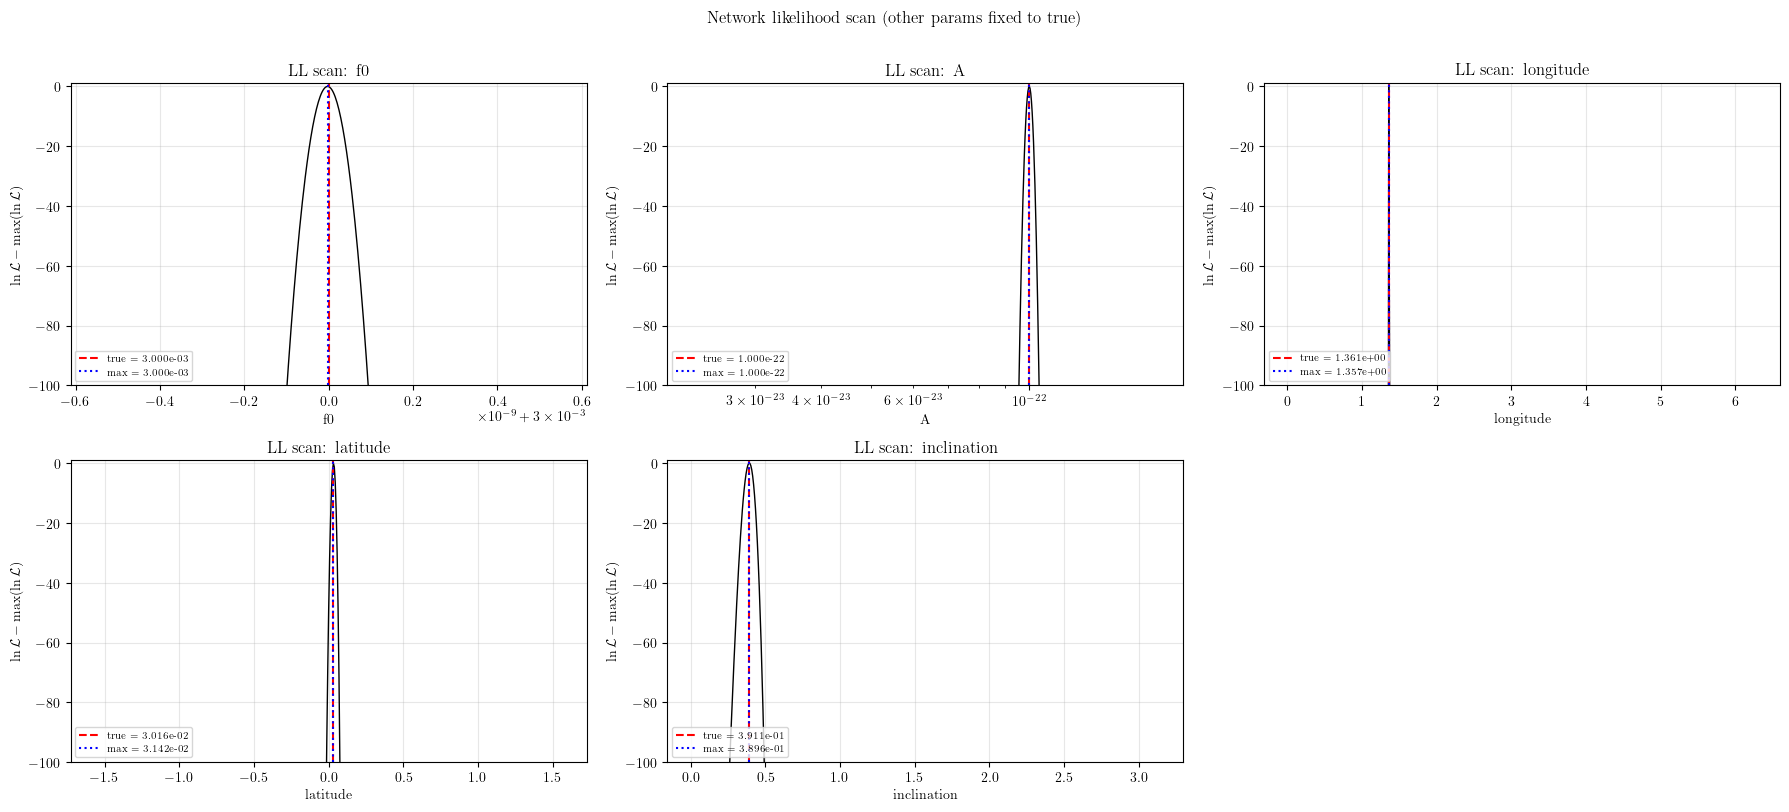

In [11]:
# ============================================================
# Likelihood scan: verify the LL peaks at the true values
# ============================================================
scan_params = ["f0", "A", "longitude", "latitude", "inclination", "psi"]
n_pts = 501

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for ax, param_name in zip(axes, scan_params):
    prior_range = priors[param_name]
    scan_grid = np.linspace(prior_range.minimum, prior_range.maximum, n_pts)
    lnL = np.zeros(n_pts)

    test_params = true_gb_parameters.copy()
    for j, val in enumerate(scan_grid):
        test_params[param_name] = val
        like.parameters = test_params
        lnL[j] = like.log_likelihood()

    lnL -= np.max(lnL)
    true_val = true_gb_parameters[param_name]
    max_idx = np.argmax(lnL)

    ax.plot(scan_grid, lnL, linewidth=1, color="k")
    if param_name == "A":
        ax.set_xscale("log")
    ax.axvline(true_val, color="red", linestyle="--", linewidth=1.5,
               label=f"true = {true_val:.3e}")
    ax.axvline(scan_grid[max_idx], color="blue", linestyle=":", linewidth=1.5,
               label=f"max  = {scan_grid[max_idx]:.3e}")
    ax.set_xlabel(param_name)
    ax.set_ylabel(r"$\ln\mathcal{L} - \max(\ln\mathcal{L})$")
    ax.legend(fontsize=7, loc="lower left")
    ax.set_title(f"LL scan: {param_name}")
    ax.set_ylim(-100, 1)
    ax.grid(alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle("Network likelihood scan (other params fixed to true)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Run PE 

In [12]:
from datetime import datetime

ncpu = multiprocessing.cpu_count()
print(f"Number of CPUs: {ncpu}")

result = bilby.run_sampler(
    likelihood=like,
    priors=priors,
    sampler="nessai",
    nlive=1000,
    stopping=0.1,
    npool=ncpu,
    injection_parameters=true_gb_parameters,
    outdir="Samples",
    label="gb_network_analysis_example",
    plot=True,
    resume=False,
)

11:41 bilby INFO    : Running for label 'gb_network_analysis_example', output will be saved to 'Samples'


Number of CPUs: 12


/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/bilby/core/utils/log.py:73: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  vdict[key] = str(getattr(sys.modules[key], "__version__", "N/A"))
11:41 bilby INFO    : Analysis priors:
11:41 bilby INFO    : A=Uniform(minimum=2.2613660909889388e-23, maximum=1.7738633909011062e-22, name='A', latex_label='$A$', unit=None, boundary=None)
11:41 bilby INFO    : f0=Uniform(minimum=0.002999999443928431, maximum=0.003000000556071569, name='f0', latex_label='$f_0$', unit=None, boundary=None)
11:41 bilby INFO    : latitude=Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='latitude', latex_label='$\\beta$', unit=None, boundary=None)
11:41 bilby INFO    : longitude=Uniform(minimum=0.0, maximum=6.283185307179586, name='longitude', latex_label='$\\lambda$', unit=None, boundary='periodic

09-16 11:41 nessai INFO    : Running Nessai version 0.14.0.post0
09-16 11:41 nessai INFO    : Starting multiprocessing pool with 12 processes


/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/nessai/utils/logging.py:133: FutureWarning: setup_logger is deprecated, use configure_logger instead
  warnings.warn(


09-16 11:41 nessai INFO    : Initialising nested sampler
09-16 11:41 nessai WARNING : Multiprocessing pool has already been configured.
09-16 11:41 nessai WARNING : Removing unused keyword arguments ({'plot_chain', 'step_type', 'augment_dims', 'plot_history', 'n_steps', 'generate_augment', 'step_kwargs', 'max_n_clusters', 'n_marg', 'n_accept', 'marginalise_augment', 'ensemble_fraction', 'enforce_likelihood_threshold'}) from kwargs for FlowProposal. These are valid keyword arguments but correspond to other proposal classes.
09-16 11:41 nessai INFO    : Passing kwargs to FlowProposal: {'training_config': None, 'poolsize': 1000, 'check_acceptance': False, 'max_poolsize_scale': 10, 'update_poolsize': True, 'accumulate_weights': False, 'save_training_data': False, 'reparameterisations': None, 'fallback_reparameterisation': 'zscore', 'use_default_reparameterisations': None, 'reverse_reparameterisations': False, 'map_to_unit_hypercube': False, 'latent_prior': 'truncated_gaussian', 'constant_v

11:57 bilby INFO    : Sampling time: 0:16:18.491784
11:57 bilby INFO    : Summary of results:
nsamples: 4650
ln_noise_evidence:    nan
ln_evidence: -19105.434 +/-  0.176
ln_bayes_factor:    nan +/-  0.176



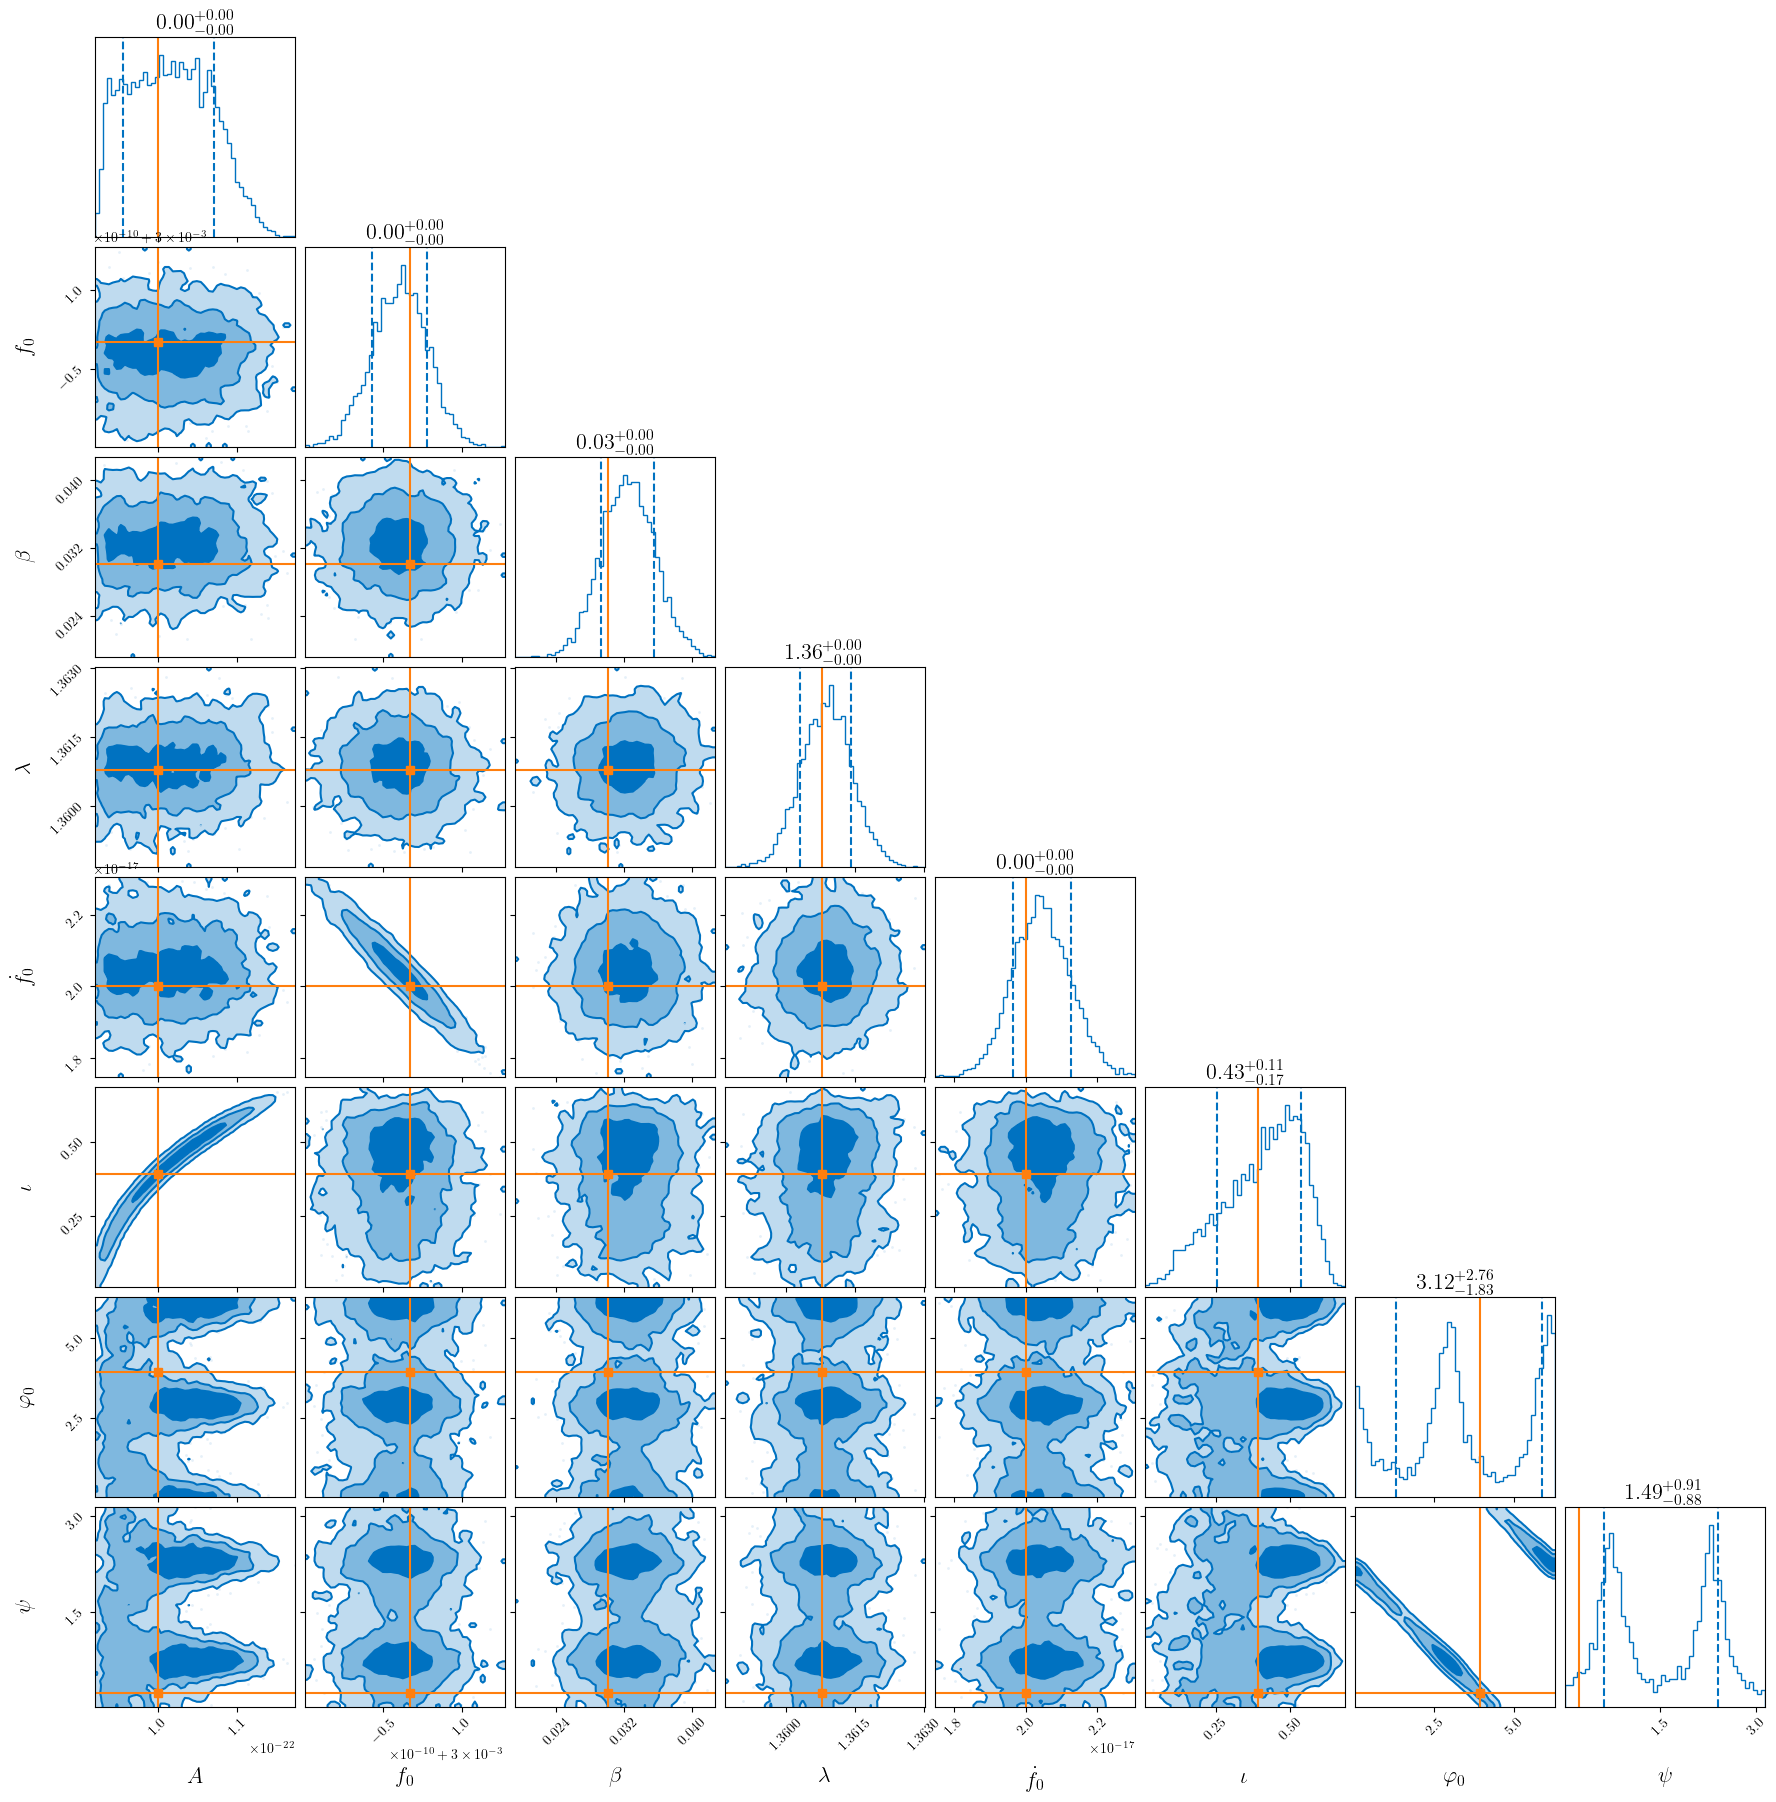

In [13]:
result.plot_corner(save=True)